In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
import warnings
from google.colab import drive


In [ ]:
# menetapkan style visualisasi diawal agar konsisten
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
drive.mount('/content/drive')

path_to_file = '/content/drive/MyDrive/idAI/dataset/fraudTrain.csv'
df_bank = pd.read_csv(path_to_file)

Mounted at /content/drive


In [4]:
print(f"Dataset shape: {df_bank.shape}")
print(f"Memory usage: {df_bank.memory_usage().sum() / 1024**2:.2f} MB")

Dataset shape: (1296675, 23)
Memory usage: 227.54 MB


EXPLORATORY DATA ANALYSIS

In [5]:
df_bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  object 
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  object 
 4   category               1296675 non-null  object 
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  object 
 7   last                   1296675 non-null  object 
 8   gender                 1296675 non-null  object 
 9   street                 1296675 non-null  object 
 10  city                   1296675 non-null  object 
 11  state                  1296675 non-null  object 
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long              

In [6]:
df_bank.describe()

,Unnamed: 0,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03
std,3.743180e+05,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02
min,0.000000e+00,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00
25%,3.241685e+05,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00
50%,6.483370e+05,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00
75%,9.725055e+05,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00
max,1.296674e+06,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00


In [8]:
missing_values = df_bank.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.sum() > 0 else "Tidak ada missing values")

Tidak ada missing values


In [9]:
fraud_dist = df_bank['is_fraud'].value_counts(normalize=True) * 100
print("\nDistribusi kelas target:")
print(f"Non-fraud: {fraud_dist[0]:.2f}%")
print(f"Fraud: {fraud_dist[1]:.2f}%")


Distribusi kelas target:
Non-fraud: 99.42%
Fraud: 0.58%


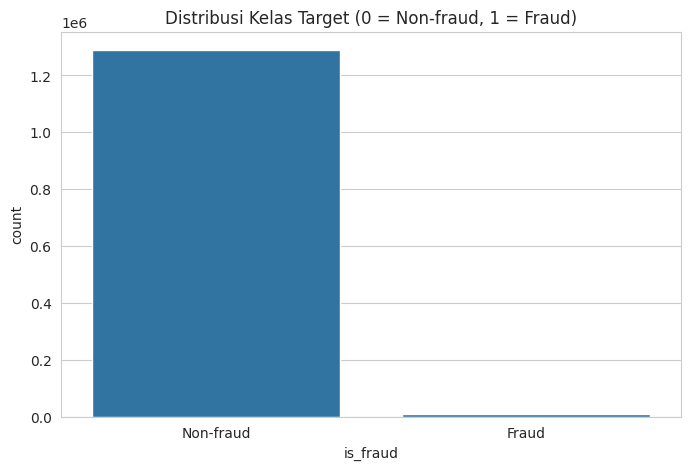

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(x='is_fraud', data=df_bank)
plt.title('Distribusi Kelas Target (0 = Non-fraud, 1 = Fraud)')
plt.xticks([0, 1], ['Non-fraud', 'Fraud'])
plt.show()

DATA PREPROCESSING

In [11]:
df_bank = df_bank.drop(columns=['trans_num'])

In [12]:
df = df_bank.copy()

In [13]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])

FEATURE ENGINEERING

In [14]:
df['transaction_hour'] = df['trans_date_trans_time'].dt.hour
df['transaction_day'] = df['trans_date_trans_time'].dt.dayofweek  # 0 = Senin, 6 = Minggu
df['is_weekend'] = df['transaction_day'].isin([5, 6]).astype(int)  # Sabtu atau Minggu
df['transaction_month'] = df['trans_date_trans_time'].dt.month

In [15]:
df['user_age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year

In [17]:
def haversine_distance(lat1, lon1, lat2, lon2):
    """Menghitung jarak antara dua titik koordinat menggunakan Haversine formula"""
    # Konversi ke radian
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    r = 6371  # Radius Bumi dalam kilometer

    return c * r

# Aplikasikan formula Haversine
df['distance_km'] = haversine_distance(
    df['lat'], df['long'],
    df['merch_lat'], df['merch_long']
)

In [19]:
# Encode variabel kategorikal
categorical_cols = ['gender', 'category', 'job', 'state']

In [20]:
# Membuat dictionary untuk menyimpan label encoder
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} kelas unik")

Encoded gender: 2 kelas unik
Encoded category: 14 kelas unik
Encoded job: 494 kelas unik
Encoded state: 51 kelas unik


In [21]:
# Menampilkan beberapa fitur baru yang dibuat
print("\nPreview fitur hasil engineering:")
print(df[['transaction_hour', 'transaction_day', 'is_weekend', 'user_age', 'distance_km']].head())


Preview fitur hasil engineering:
   transaction_hour  transaction_day  is_weekend  user_age  distance_km
0                 0                1           0        31    78.597568
1                 0                1           0        41    30.212176
2                 0                1           0        57   108.206083
3                 0                1           0        52    95.673231
4                 0                1           0        33    77.556744


ANALISIS LANJUTAN & VISUALISASI

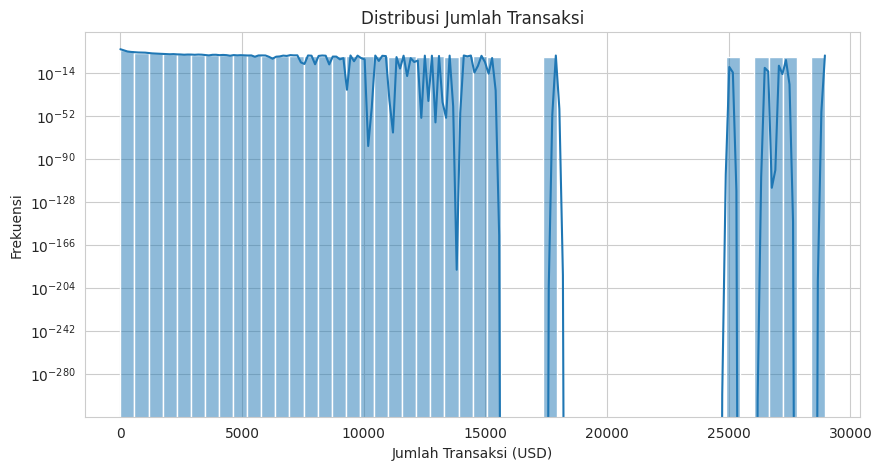

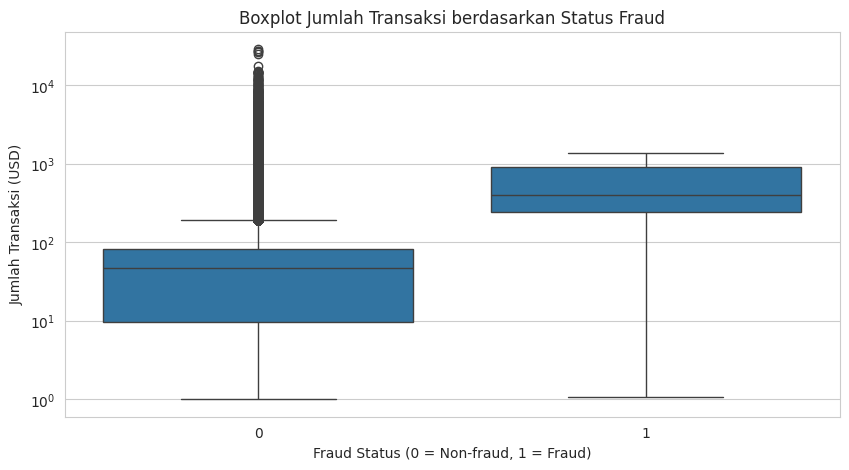

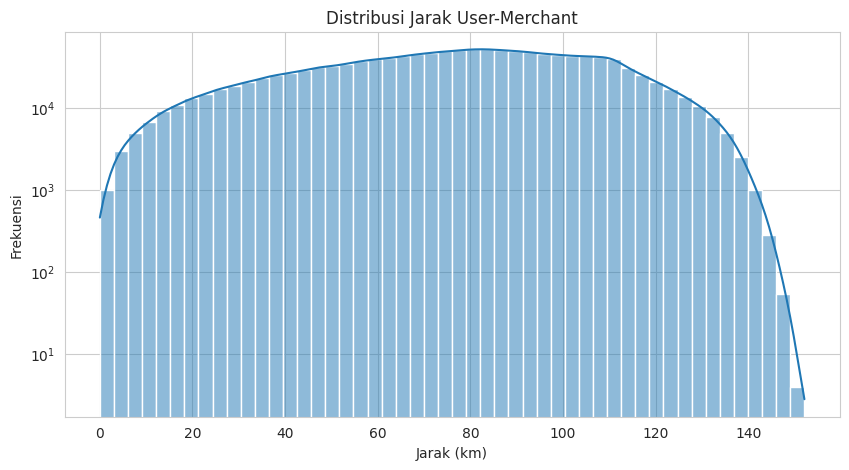

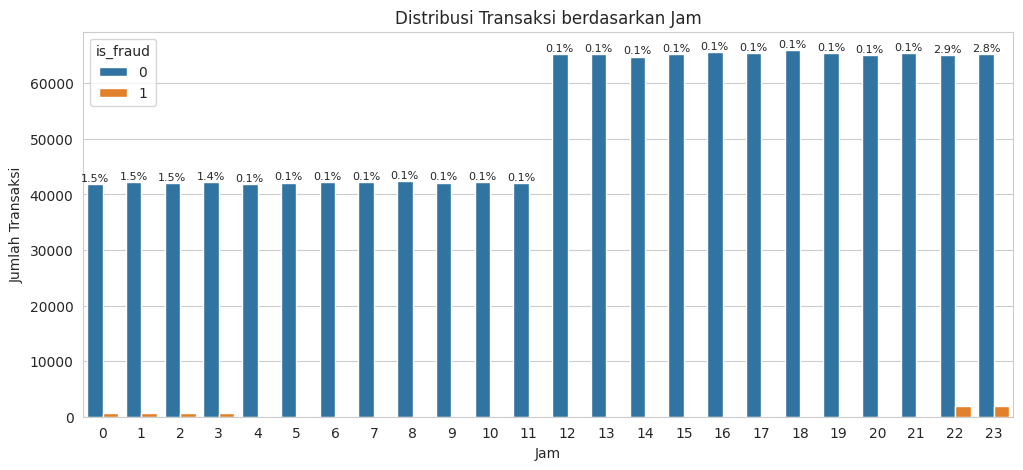

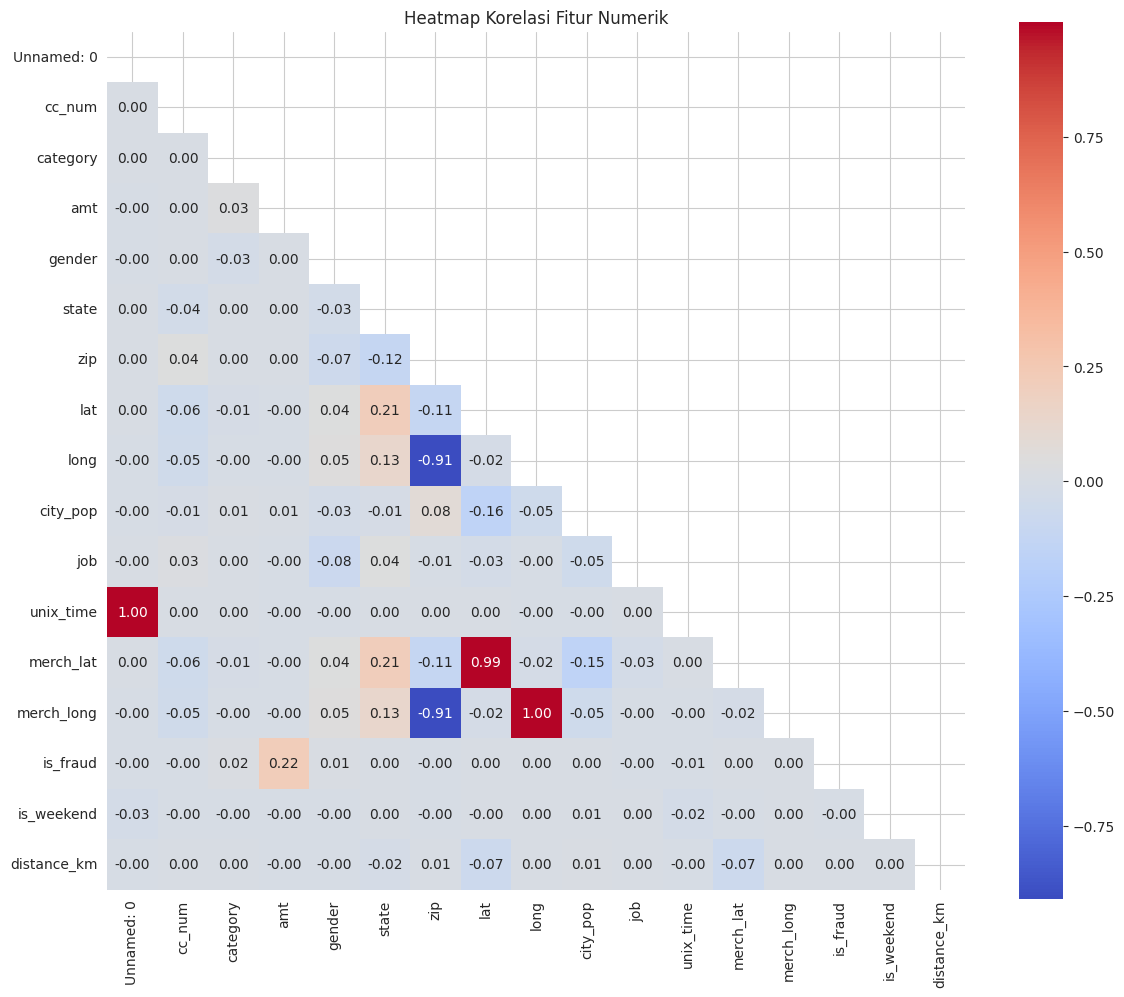

In [24]:

# 1. Distribusi jumlah transaksi
plt.figure(figsize=(10, 5))
sns.histplot(df['amt'], bins=50, kde=True)
plt.title('Distribusi Jumlah Transaksi')
plt.xlabel('Jumlah Transaksi (USD)')
plt.ylabel('Frekuensi')
plt.yscale('log')  # Skala log untuk visualisasi yang lebih baik
plt.show()

# 2. Boxplot jumlah transaksi berdasarkan status fraud
plt.figure(figsize=(10, 5))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.title('Boxplot Jumlah Transaksi berdasarkan Status Fraud')
plt.xlabel('Fraud Status (0 = Non-fraud, 1 = Fraud)')
plt.ylabel('Jumlah Transaksi (USD)')
plt.yscale('log')  # Skala log untuk visualisasi yang lebih baik
plt.show()

# 3. Distribusi jarak user-merchant
plt.figure(figsize=(10, 5))
sns.histplot(df['distance_km'], bins=50, kde=True)
plt.title('Distribusi Jarak User-Merchant')
plt.xlabel('Jarak (km)')
plt.ylabel('Frekuensi')
plt.yscale('log')  # Skala log untuk visualisasi yang lebih baik
plt.show()

# 4. Distribusi transaksi berdasarkan jam
plt.figure(figsize=(12, 5))
ax = sns.countplot(x='transaction_hour', hue='is_fraud', data=df)
plt.title('Distribusi Transaksi berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Transaksi')

# Hitung persentase fraud per jam
fraud_by_hour = df.groupby('transaction_hour')['is_fraud'].mean() * 100
for i, p in enumerate(ax.patches[:24]):  # Only first 24 patches (for hour 0-23)
    hour = i % 24
    ax.annotate(f"{fraud_by_hour[hour]:.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height() + 500),
                ha='center', fontsize=8)
plt.show()

# 5. Heatmap korelasi
# Pilih hanya kolom numerik
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
corr = df[numeric_cols].corr()

# Visualisasi korelasi
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Mask untuk membuat heatmap segitiga
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, square=True)
plt.title('Heatmap Korelasi Fitur Numerik')
plt.tight_layout()
plt.show()

PERSIAPAN DATA UNTUK MODELING

In [25]:
columns_to_drop = [
    'trans_date_trans_time',  # Sudah diekstrak ke fitur lain
    'dob',                    # Sudah dihitung menjadi user_age
    'cc_num',                 # Informasi sensitif dan tidak relevan
    'first',                  # Nama depan tidak relevan
    'last',                   # Nama belakang tidak relevan
    'street',                 # Detail alamat tidak relevan
    'city',                   # Detail kota sudah tercakup dalam city_pop
    'zip',                    # Kode pos tidak relevan
    'unix_time',              # Waktu sudah diekstrak ke fitur lain
    'merchant'                # Nama merchant tidak relevan
]

In [27]:
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
df_clean = df.drop(columns=columns_to_drop)
print(f"Kolom yang dihapus: {columns_to_drop}")
print(f"Jumlah fitur tersisa: {df_clean.shape[1]}")

Kolom yang dihapus: ['trans_date_trans_time', 'dob', 'cc_num', 'first', 'last', 'street', 'city', 'zip', 'unix_time', 'merchant']
Jumlah fitur tersisa: 18


In [28]:
# Cek fitur yang berkorelasi tinggi (redundant)
threshold = 0.8
redundant_pairs = []

for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > threshold:
            redundant_pairs.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

if redundant_pairs:
    print("\nPasangan fitur dengan korelasi tinggi (>0.8):")
    for col1, col2, corr_val in redundant_pairs:
        print(f"{col1} - {col2}: {corr_val:.4f}")

# Berdasarkan analisis korelasi, hapus fitur redundant
redundant_features = ['merch_lat', 'long', 'merch_long']  # Fitur yang berkorelasi tinggi
redundant_features = [col for col in redundant_features if col in df_clean.columns]

df_clean = df_clean.drop(columns=redundant_features)
print(f"\nSetelah menghapus fitur redundant, jumlah fitur: {df_clean.shape[1]}")



Pasangan fitur dengan korelasi tinggi (>0.8):
long - zip: -0.9097
unix_time - Unnamed: 0: 0.9990
merch_lat - lat: 0.9936
merch_long - zip: -0.9089
merch_long - long: 0.9991

Setelah menghapus fitur redundant, jumlah fitur: 15


In [29]:
# Standardisasi fitur numerik
numerical_features = ['amt', 'lat', 'city_pop', 'user_age', 'distance_km']
numerical_features = [col for col in numerical_features if col in df_clean.columns]

scaler = StandardScaler()
df_clean[numerical_features] = scaler.fit_transform(df_clean[numerical_features])


TRAIN-TEST SPLIT

In [30]:
# Pisahkan fitur dan target
X = df_clean.drop(columns=['is_fraud'])
y = df_clean['is_fraud']

# Split data (stratified untuk menangani imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} sampel ({X_train.shape[1]} fitur)")
print(f"Testing set: {X_test.shape[0]} sampel ({X_test.shape[1]} fitur)")


Training set: 1037340 sampel (14 fitur)
Testing set: 259335 sampel (14 fitur)


In [32]:
# Cek proporsi kelas dalam data training dan testing
print(f"Proporsi fraud di training: {y_train.mean():.4f}")
print(f"Proporsi fraud di testing: {y_test.mean():.4f}")

Proporsi fraud di training: 0.0058
Proporsi fraud di testing: 0.0058


FEATURE ENGINEERING POST-SPLIT

In [33]:
# 1. Fraud rate by category (hanya menggunakan data training)
fraud_rate_by_category = pd.DataFrame(y_train).join(X_train['category']).groupby('category')['is_fraud'].mean()

# Terapkan ke data training dan testing
X_train['fraud_rate_category'] = X_train['category'].map(fraud_rate_by_category)
X_test['fraud_rate_category'] = X_test['category'].map(fraud_rate_by_category)

print("Feature engineering post-split selesai")

Feature engineering post-split selesai


MODEL TRAINING & EVALUATION

In [34]:
print("\n1. Melatih Random Forest dengan parameter default...")
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)


1. Melatih Random Forest dengan parameter default...


RandomForestClassifier(n_jobs=-1, random_state=42)

In [35]:
# Prediksi dan evaluasi
y_pred_rf = rf_model.predict(X_test)
print("Hasil evaluasi Random Forest:")
print(classification_report(y_test, y_pred_rf))

Hasil evaluasi Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.98      0.77      0.86      1501

    accuracy                           1.00    259335
   macro avg       0.99      0.88      0.93    259335
weighted avg       1.00      1.00      1.00    259335



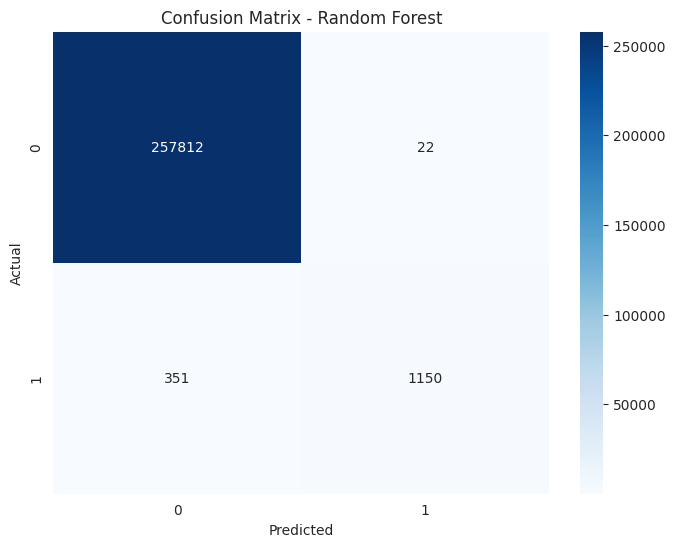

In [36]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


2. Melatih XGBoost dengan Hyperparameter Tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:29:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Parameter terbaik XGBoost:
{'subsample': 1.0, 'scale_pos_weight': 1, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Hasil evaluasi XGBoost:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.96      0.78      0.86      1501

    accuracy                           1.00    259335
   macro avg       0.98      0.89      0.93    259335
weighted avg       1.00      1.00      1.00    259335



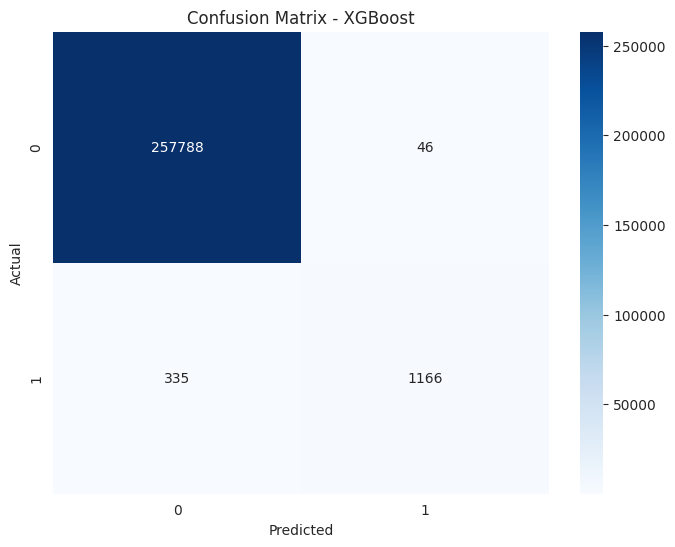

In [37]:
print("\n2. Melatih XGBoost dengan Hyperparameter Tuning...")

# Inisialisasi model XGBoost
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Tentukan parameter yang ingin diuji (jumlah lebih sedikit dari sebelumnya)
param_dist = {
    'n_estimators': [50, 100],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'scale_pos_weight': [1, sum(y_train==0)/sum(y_train==1)]  # Adjusting for class imbalance
}

# RandomizedSearchCV dengan iterasi lebih sedikit
random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=10,  # Reduced from 50
    cv=3,       # 3-fold cross-validation
    scoring='f1',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Training
random_search.fit(X_train, y_train)

# Hasil terbaik
print("\nParameter terbaik XGBoost:")
print(random_search.best_params_)

# Evaluasi model terbaik
best_model = random_search.best_estimator_
y_pred_xgb = best_model.predict(X_test)

print("\nHasil evaluasi XGBoost:")
print(classification_report(y_test, y_pred_xgb))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

MODEL STACKING

Melatih Stacking Model...

Hasil evaluasi Stacking Model:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    257834
           1       0.96      0.82      0.89      1501

    accuracy                           1.00    259335
   macro avg       0.98      0.91      0.94    259335
weighted avg       1.00      1.00      1.00    259335



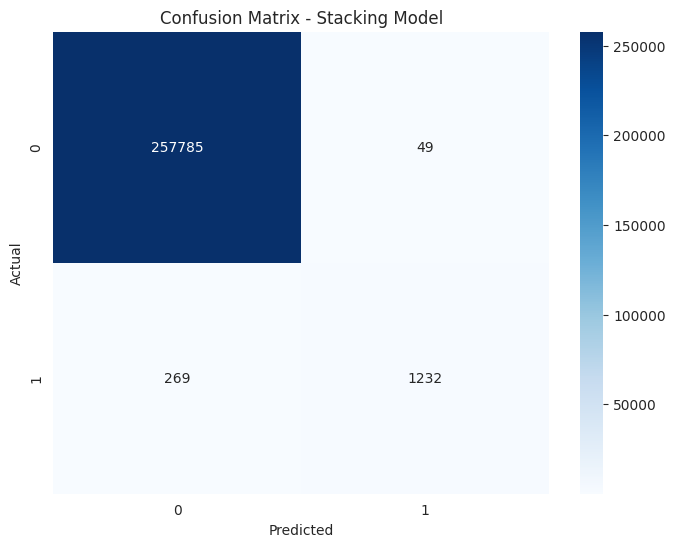

In [38]:
# Definisikan model dasar (base models)
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
    ('xgb', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss',
                            **random_search.best_params_))  # Use best parameters from tuning
]

# Meta-model
meta_model = LogisticRegression(solver='liblinear', random_state=42)

# Inisialisasi StackingClassifier
stacking_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_model,
    cv=3,
    n_jobs=-1
)

# Latih model
print("Melatih Stacking Model...")
stacking_model.fit(X_train, y_train)

# Prediksi
y_pred_stacking = stacking_model.predict(X_test)

# Evaluasi
print("\nHasil evaluasi Stacking Model:")
print(classification_report(y_test, y_pred_stacking))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_stacking)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Stacking Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

ANALISIS FEATURE IMPORTANCE

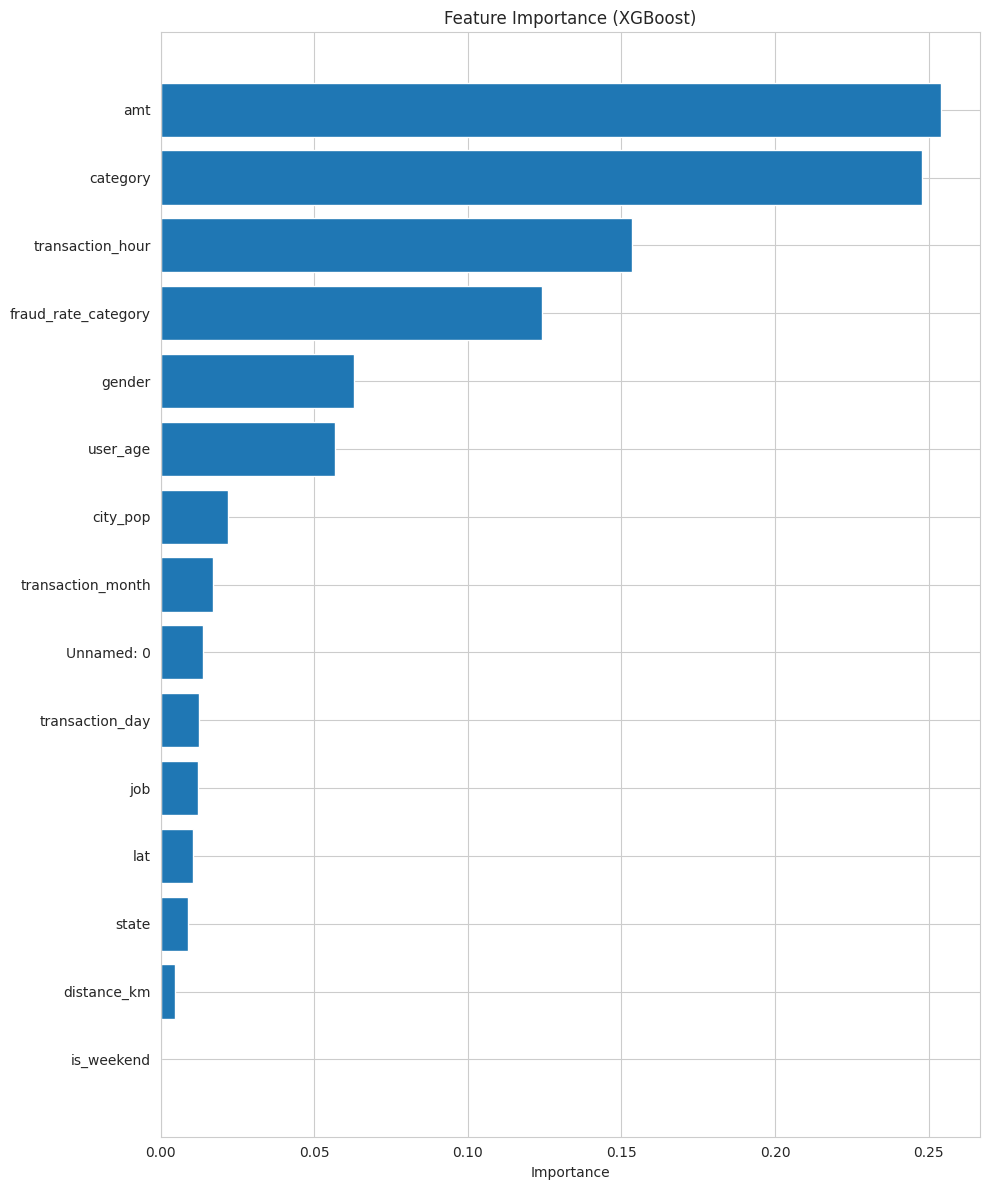


Top 10 fitur paling penting:
                Feature  Importance
2                   amt    0.254055
1              category    0.247713
8      transaction_hour    0.153454
14  fraud_rate_category    0.124013
3                gender    0.062819
12             user_age    0.056645
6              city_pop    0.022059
11    transaction_month    0.016896
0            Unnamed: 0    0.013635
9       transaction_day    0.012484


In [39]:
# Feature importance dari model terbaik (XGBoost)
feature_importance = best_model.feature_importances_
feature_names = X_train.columns

# Urutkan feature importance
sorted_idx = np.argsort(feature_importance)
plt.figure(figsize=(10, 12))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), [feature_names[i] for i in sorted_idx])
plt.title('Feature Importance (XGBoost)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print("\nTop 10 fitur paling penting:")
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print(importance_df.head(10))


PERBANDINGAN MODEL & KESIMPULAN

Perbandingan performa model (ROC AUC):
             Model   ROC AUC
0    Random Forest  0.992475
1  XGBoost (Tuned)  0.997299
2         Stacking  0.997857


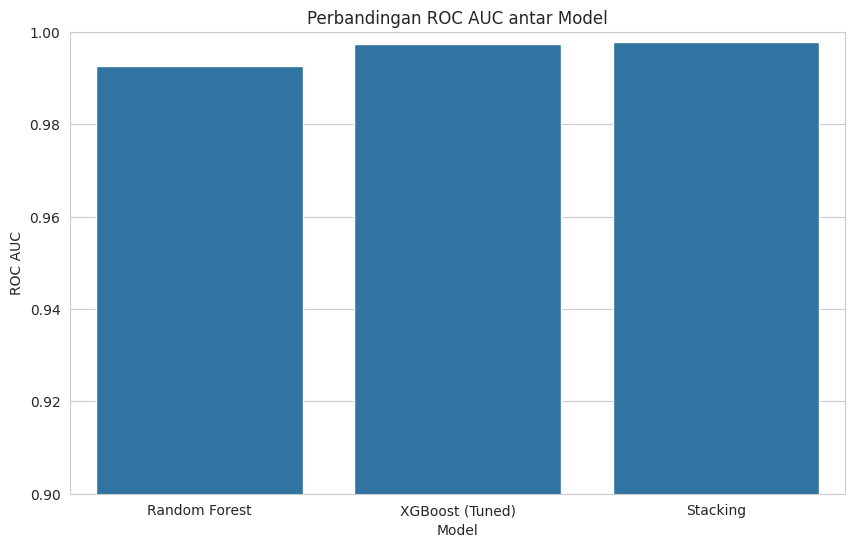


KESIMPULAN:
Model terbaik adalah Stacking dengan ROC AUC 0.9979
Analisis feature importance menunjukkan fitur-fitur yang paling berpengaruh dalam deteksi fraud.
Model dapat digunakan untuk mendeteksi transaksi fraud dengan performa yang baik.


In [40]:

# Hitung ROC AUC untuk semua model
roc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])
roc_xgb = roc_auc_score(y_test, best_model.predict_proba(X_test)[:, 1])
roc_stacking = roc_auc_score(y_test, stacking_model.predict_proba(X_test)[:, 1])

# DataFrame untuk perbandingan
model_comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost (Tuned)', 'Stacking'],
    'ROC AUC': [roc_rf, roc_xgb, roc_stacking]
})

print("Perbandingan performa model (ROC AUC):")
print(model_comparison)

# Plot perbandingan
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='ROC AUC', data=model_comparison)
plt.title('Perbandingan ROC AUC antar Model')
plt.ylim(0.9, 1.0)  # Adjust as needed to better see differences
plt.show()

print("\nKESIMPULAN:")
best_model_name = model_comparison.loc[model_comparison['ROC AUC'].idxmax(), 'Model']
print(f"Model terbaik adalah {best_model_name} dengan ROC AUC {model_comparison['ROC AUC'].max():.4f}")
print("Analisis feature importance menunjukkan fitur-fitur yang paling berpengaruh dalam deteksi fraud.")
print("Model dapat digunakan untuk mendeteksi transaksi fraud dengan performa yang baik.")
